# 02 — Benchmark pédagogique des modèles de détection

Ce notebook prépare les features, entraîne **Isolation Forest**, **LOF** et un **autoencoder**, puis compare précision, rappel, F1-score, ROC-AUC et temps d'exécution. La seed est fixée à `42`. Pour conserver un temps compatible avec un ordinateur CPU, le benchmark utilise 10 000 transactions et 10 epochs pour l'autoencoder.

In [1]:
from pathlib import Path
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (10, 5), 'figure.dpi': 110})

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'backend' / 'src' / 'mauripay').exists():
            return candidate
    raise RuntimeError('Racine MauriPay-Analytics introuvable')

ROOT = find_project_root()
sys.path.insert(0, str(ROOT / 'backend' / 'src'))
DATA_DIR = ROOT / 'data' / 'generated'
OUTPUT_DIR = ROOT / 'notebooks' / 'outputs' / '02_benchmark'
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
np.random.seed(SEED)
print(f'Racine : {ROOT}')

Racine : D:\mauripay-analytics


## Dataset reproductible
Le notebook est autonome : il génère son dataset de 10 000 lignes si nécessaire.

In [2]:
from mauripay.detection.io import load_table
from mauripay.synthetic.exporters import export_transactions
from mauripay.synthetic.generator import generate_transactions

DATA_PATH = DATA_DIR / 'mauripay_s_notebook_10k.parquet'
if not DATA_PATH.exists():
    transactions = generate_transactions(rows=10_000, seed=SEED)
    export_transactions(transactions, DATA_PATH)
    del transactions

df = load_table(DATA_PATH).sort_values('timestamp').reset_index(drop=True)
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()
y_test = test_df['is_anomaly'].astype(str).str.lower().isin(['true', '1', 'yes']).astype(int).to_numpy()
print(f'Entraînement : {len(train_df):,} lignes')
print(f'Évaluation   : {len(test_df):,} lignes, {y_test.sum():,} anomalies')

Entraînement : 8,000 lignes
Évaluation   : 2,000 lignes, 139 anomalies


## Préparation des features
Les identifiants et labels sont exclus. Le préprocesseur apprend les catégories et la standardisation uniquement sur le jeu d'entraînement. Un second préprocesseur est ajusté sur les lignes normales pour l'autoencoder.

In [3]:
from mauripay.detection.features import TransactionFeatureEngineer

feature_start = time.perf_counter()
classical_preprocessor = TransactionFeatureEngineer()
X_train = classical_preprocessor.fit_transform(train_df)
X_test = classical_preprocessor.transform(test_df)
classical_feature_seconds = time.perf_counter() - feature_start

normal_mask = ~train_df['is_anomaly'].astype(str).str.lower().isin(['true', '1', 'yes'])
normal_train_df = train_df.loc[normal_mask].copy()
ae_feature_start = time.perf_counter()
autoencoder_preprocessor = TransactionFeatureEngineer()
X_ae_train = autoencoder_preprocessor.fit_transform(normal_train_df)
X_ae_test = autoencoder_preprocessor.transform(test_df)
ae_feature_seconds = time.perf_counter() - ae_feature_start

print(f'Features classiques : {X_train.shape[1]} colonnes en {classical_feature_seconds:.2f} s')
print(f'Features autoencoder : {X_ae_train.shape[1]} colonnes en {ae_feature_seconds:.2f} s')

Features classiques : 167 colonnes en 22.16 s
Features autoencoder : 166 colonnes en 21.49 s


## Entraînement et évaluation
Les temps de `fit` et de prédiction sont mesurés séparément. Le feature engineering est présenté au-dessus et n'est pas inclus dans ces temps.

In [4]:
from mauripay.detection.autoencoder import AutoencoderDetector
from mauripay.detection.iforest import IsolationForestDetector
from mauripay.detection.lof import LOFDetector
from mauripay.detection.metrics import evaluate_detection

def benchmark_detector(name, detector, X_fit, X_eval):
    started = time.perf_counter()
    detector.fit(X_fit)
    train_seconds = time.perf_counter() - started
    started = time.perf_counter()
    predictions = detector.results(X_eval)
    inference_seconds = time.perf_counter() - started
    metrics = evaluate_detection(
        y_test,
        predictions['anomaly_label'].to_numpy(),
        predictions['anomaly_score'].to_numpy(),
    )
    return {
        'modèle': name,
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1_score': metrics['f1_score'],
        'accuracy': metrics['accuracy'],
        'roc_auc': metrics.get('roc_auc', np.nan),
        'train_s': train_seconds,
        'inference_s': inference_seconds,
        'alertes': int(predictions['anomaly_label'].sum()),
        'matrice_confusion': metrics['confusion_matrix'],
    }

detectors = [
    ('Isolation Forest', IsolationForestDetector(n_estimators=100, contamination=0.02, random_state=SEED), X_train, X_test),
    ('LOF', LOFDetector(n_neighbors=20, contamination=0.02, metric='minkowski'), X_train, X_test),
    ('Autoencoder', AutoencoderDetector(encoding_dim=8, hidden_dims=(32, 16), epochs=10, batch_size=128, threshold_percentile=98, random_state=SEED, device='cpu'), X_ae_train, X_ae_test),
]

results = []
for name, detector, X_fit, X_eval in detectors:
    print(f'Entraînement : {name}...')
    results.append(benchmark_detector(name, detector, X_fit, X_eval))
print('Terminé.')

Entraînement : Isolation Forest...
Entraînement : LOF...
Entraînement : Autoencoder...
Terminé.


## Comparaison finale

In [5]:
results_df = pd.DataFrame(results).set_index('modèle')
display(results_df.drop(columns='matrice_confusion').round(4))
print('Matrices de confusion [[TN, FP], [FN, TP]] :')
for model_name, row in results_df.iterrows():
    print(f"{model_name:18s} : {row['matrice_confusion']}")
results_df.drop(columns='matrice_confusion').to_csv(OUTPUT_DIR / 'comparaison_modeles.csv')

,precision,recall,f1_score,accuracy,roc_auc,train_s,inference_s,alertes
modèle,,,,,,,,
Isolation Forest,1.0000,0.1799,0.3049,0.943,0.9448,0.6411,0.0345,25
LOF,0.3659,0.1079,0.1667,0.925,0.4512,5.4784,0.3769,41
Autoencoder,0.8271,0.7914,0.8088,0.974,0.9382,10.7364,0.0091,133


Matrices de confusion [[TN, FP], [FN, TP]] :
Isolation Forest   : [[1861, 0], [114, 25]]
LOF                : [[1835, 26], [124, 15]]
Autoencoder        : [[1838, 23], [29, 110]]


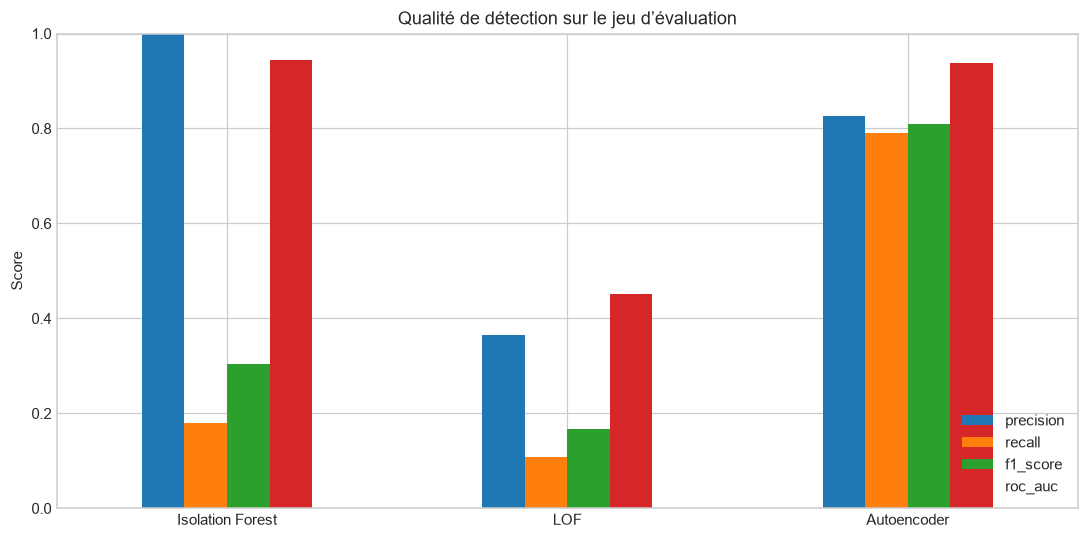

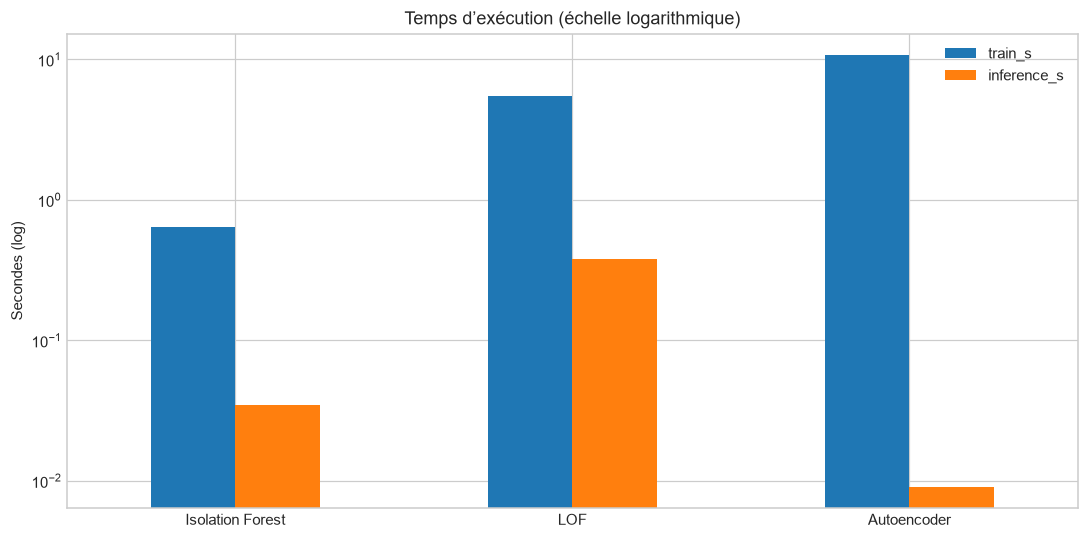

Résultats exportés dans : D:\mauripay-analytics\notebooks\outputs\02_benchmark


In [6]:
metric_columns = ['precision', 'recall', 'f1_score', 'roc_auc']
ax = results_df[metric_columns].plot.bar(rot=0, ylim=(0, 1), title='Qualité de détection sur le jeu d’évaluation')
ax.set(ylabel='Score', xlabel='')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparaison_metriques.png', bbox_inches='tight')
plt.show()

ax = results_df[['train_s', 'inference_s']].plot.bar(rot=0, logy=True, title='Temps d’exécution (échelle logarithmique)')
ax.set(ylabel='Secondes (log)', xlabel='')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparaison_temps.png', bbox_inches='tight')
plt.show()
print(f'Résultats exportés dans : {OUTPUT_DIR}')

## Interprétation
- La **précision** mesure la part des alertes réellement anormales.
- Le **rappel** mesure la part des anomalies injectées retrouvées.
- Le **F1-score** équilibre précision et rappel.
- Les temps dépendent du matériel ; les métriques dépendent aussi du split temporel et des hyperparamètres.

Ce benchmark est pédagogique. Pour une évaluation scientifique finale, répéter l'expérience avec plusieurs seeds et un protocole temporel indépendant.